# Argoverse 2 Motion Forecasting: Read and Inspect Locally

This notebook mirrors `waymo_motion.ipynb`, but for Argoverse 2 Motion Forecasting data stored locally.

- Expected env var: `AV2_DATA_ROOT`
- Expected layout: `<root>/<split>/<scenario_id>/scenario_<scenario_id>.parquet` and `log_map_archive_<scenario_id>.json`
- Goal: learn how to open one scenario, inspect tracks, inspect the vector map, and visualize tracks on top of the map

## 1) Installation (run once per environment)

1. `uv sync`
2. Ensure `AV2_DATA_ROOT` is set, for example in `.env`
3. Open the notebook with the project environment kernel

## 2) Imports and global config

In [1]:
from pathlib import Path
from dotenv import load_dotenv
from io import BytesIO
import os
import random

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import numpy as np
import pandas as pd
from IPython.display import Image, display

from av2.datasets.motion_forecasting import scenario_serialization
from av2.map.map_api import ArgoverseStaticMap

load_dotenv()

DATASET_ROOT = Path(os.environ.get('AV2_DATA_ROOT', ''))
print('Dataset root exists:', DATASET_ROOT.exists())
print('Dataset root:', DATASET_ROOT)


Dataset root exists: True
Dataset root: /mnt/disk/data/public/argoverse/v2/motion


## 3) Discover scenario folders

This searches under the dataset root for split folders and scenario directories.

In [2]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError('AV2_DATA_ROOT is not set correctly or the path does not exist.')

candidate_splits = ['train', 'val', 'test', 'mini_train', 'mini_val']
available_splits = [split for split in candidate_splits if (DATASET_ROOT / split).exists()]
print('Available splits:', available_splits)

scenario_dirs_by_split = {}
for split in available_splits:
    split_dir = DATASET_ROOT / split
    scenario_dirs = sorted(path for path in split_dir.iterdir() if path.is_dir())
    scenario_dirs_by_split[split] = scenario_dirs
    print(f'{split}: {len(scenario_dirs)} scenarios')
    for path in scenario_dirs[:5]:
        print(' -', path)


Available splits: ['train', 'val', 'test', 'mini_train']
train: 199908 scenarios
 - /mnt/disk/data/public/argoverse/v2/motion/train/0000b0f9-99f9-4a1f-a231-5be9e4c523f7
 - /mnt/disk/data/public/argoverse/v2/motion/train/0000b6ab-e100-4f6b-aee8-b520b57c0530
 - /mnt/disk/data/public/argoverse/v2/motion/train/0001b567-b7ac-4a91-b4fe-6132e4b81884
 - /mnt/disk/data/public/argoverse/v2/motion/train/0001f576-0552-49c9-9ce2-8c47411a088e
 - /mnt/disk/data/public/argoverse/v2/motion/train/0001fe2b-a3c8-4cdf-a712-6b65a17ca316
val: 24988 scenarios
 - /mnt/disk/data/public/argoverse/v2/motion/val/00010486-9a07-48ae-b493-cf4545855937
 - /mnt/disk/data/public/argoverse/v2/motion/val/00062a32-8d6d-4449-9948-6fedac67bfcd
 - /mnt/disk/data/public/argoverse/v2/motion/val/0006ca28-fcbb-4ae2-9d9e-951fa3b41c1c
 - /mnt/disk/data/public/argoverse/v2/motion/val/0007df76-c9a2-47aa-83bf-3b2b414109c9
 - /mnt/disk/data/public/argoverse/v2/motion/val/0015197d-b916-43b6-bcaa-8a7d90d7b87d
test: 24984 scenarios
 - /mn

## 4) Pick one scenario and load it

Each AV2 motion scenario lives in one directory with a parquet trajectory file and a static map JSON.

In [3]:
if not scenario_dirs_by_split:
    raise FileNotFoundError(f'No scenario folders found under {DATASET_ROOT}')

SELECTED_SPLIT = available_splits[0]
scenario_dirs = scenario_dirs_by_split[SELECTED_SPLIT]
if not scenario_dirs:
    raise FileNotFoundError(f'No scenarios found under {DATASET_ROOT / SELECTED_SPLIT}')

SCENARIO_DIR = scenario_dirs[0]  # change to any scenario directory you want
SCENARIO_ID = SCENARIO_DIR.name
PARQUET_PATH = SCENARIO_DIR / f'scenario_{SCENARIO_ID}.parquet'
MAP_PATH = SCENARIO_DIR / f'log_map_archive_{SCENARIO_ID}.json'

print('Selected split:', SELECTED_SPLIT)
print('Scenario dir:', SCENARIO_DIR)
print('Parquet exists:', PARQUET_PATH.exists())
print('Map exists:', MAP_PATH.exists())

scenario = scenario_serialization.load_argoverse_scenario_parquet(PARQUET_PATH)
static_map = ArgoverseStaticMap.from_json(MAP_PATH)
print('Loaded scenario_id:', scenario.scenario_id)


Selected split: train
Scenario dir: /mnt/disk/data/public/argoverse/v2/motion/train/0000b0f9-99f9-4a1f-a231-5be9e4c523f7
Parquet exists: True
Map exists: True
Loaded scenario_id: 0000b0f9-99f9-4a1f-a231-5be9e4c523f7


In [4]:
print('city_name:', scenario.city_name)
print('focal_track_id:', scenario.focal_track_id)
print('num_timestamps:', len(scenario.timestamps_ns))
print('num_tracks:', len(scenario.tracks))
print('num_lane_segments:', len(static_map.vector_lane_segments))
print('num_drivable_areas:', len(static_map.vector_drivable_areas))
print('num_pedestrian_crossings:', len(static_map.vector_pedestrian_crossings))


city_name: austin
focal_track_id: 51241
num_timestamps: 110
num_tracks: 56
num_lane_segments: 25
num_drivable_areas: 3
num_pedestrian_crossings: 5


## 5) Convert track states to a table

This flattens every `(track, timestep)` into one row for quick inspection in pandas.

In [5]:
def tracks_to_dataframe(scenario_msg):
    rows = []
    for track_idx, track in enumerate(scenario_msg.tracks):
        for state in track.object_states:
            rows.append({
                'track_array_index': track_idx,
                'track_id': track.track_id,
                'object_type': str(track.object_type),
                'category': str(track.category),
                'timestep': state.timestep,
                'observed': bool(state.observed),
                'position_x': state.position[0],
                'position_y': state.position[1],
                'heading': state.heading,
                'velocity_x': state.velocity[0],
                'velocity_y': state.velocity[1],
            })
    return pd.DataFrame(rows)

tracks_df = tracks_to_dataframe(scenario)
print('rows:', len(tracks_df))
tracks_df.head(10)


rows: 2511


,track_array_index,track_id,object_type,category,timestep,observed,position_x,position_y,heading,velocity_x,velocity_y
0,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,0,True,18.591604,-414.075877,1.269081,1.889325,6.052013
1,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,1,True,18.693685,-413.747185,1.268987,1.898718,6.062060
2,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,2,True,18.819566,-413.338909,1.268902,1.902845,6.048986
3,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,3,True,18.967646,-412.857532,1.268811,1.890446,5.996844
4,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,4,True,19.136512,-412.309115,1.268704,1.877703,5.958815
5,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,5,True,19.322199,-411.705122,1.268593,1.884528,6.005102
6,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,6,True,19.519781,-411.059078,1.268494,1.909397,6.115908
7,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,7,True,19.725421,-410.382322,1.268411,1.940273,6.232463
8,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,8,True,19.934917,-409.690451,1.268297,1.969084,6.324693
9,0,50513,ObjectType.VEHICLE,TrackCategory.SCORED_TRACK,9,True,20.141767,-409.004444,1.268162,1.981913,6.366841


In [6]:
valid_df = tracks_df.dropna(subset=['position_x', 'position_y']).copy()
print('Unique tracks:', valid_df['track_id'].nunique())
print('Counts by object_type:')
display(valid_df[['track_id', 'object_type']].drop_duplicates()['object_type'].value_counts())
print('Counts by category:')
display(valid_df[['track_id', 'category']].drop_duplicates()['category'].value_counts())


Unique tracks: 56
Counts by object_type:


ObjectType.VEHICLE              47
ObjectType.STATIC                4
ObjectType.PEDESTRIAN            2
ObjectType.RIDERLESS_BICYCLE     2
ObjectType.CYCLIST               1
Name: object_type, dtype: int64

Counts by category:


TrackCategory.TRACK_FRAGMENT    51
TrackCategory.SCORED_TRACK       2
TrackCategory.UNSCORED_TRACK     2
TrackCategory.FOCAL_TRACK        1
Name: category, dtype: int64

## 6) Inspect map contents

In [7]:
lane_type_counts = pd.Series(
    [str(lane.lane_type) for lane in static_map.vector_lane_segments.values()],
    name='lane_type',
)
lane_type_counts.value_counts(dropna=False)


LaneType.VEHICLE    23
LaneType.BIKE        2
Name: lane_type, dtype: int64

## 7) Quick 2D trajectory plot

This plots valid XY history for a random subset of tracks in one scenario.

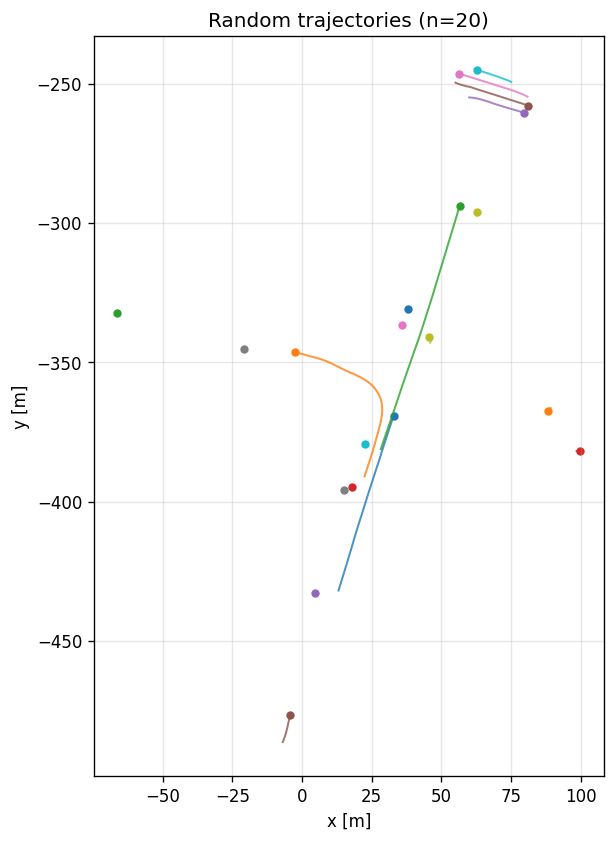

In [8]:
def plot_random_tracks(df, num_tracks=20, seed=0):
    rng = random.Random(seed)
    valid = df.dropna(subset=['position_x', 'position_y']).copy()
    track_ids = valid['track_id'].drop_duplicates().tolist()
    if not track_ids:
        raise ValueError('No valid tracks to plot.')

    chosen = set(rng.sample(track_ids, k=min(num_tracks, len(track_ids))))
    subset = valid[valid['track_id'].isin(chosen)].sort_values(['track_id', 'timestep'])

    fig = Figure(figsize=(8, 8))
    ax = fig.subplots()

    for track_id, group in subset.groupby('track_id'):
        ax.plot(group['position_x'], group['position_y'], linewidth=1.2, alpha=0.8)
        ax.scatter(group['position_x'].iloc[-1], group['position_y'].iloc[-1], s=16)

    ax.set_title(f'Random trajectories (n={len(chosen)})')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)

    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=120, bbox_inches='tight')
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    buffer.close()

plot_random_tracks(tracks_df, num_tracks=20, seed=42)


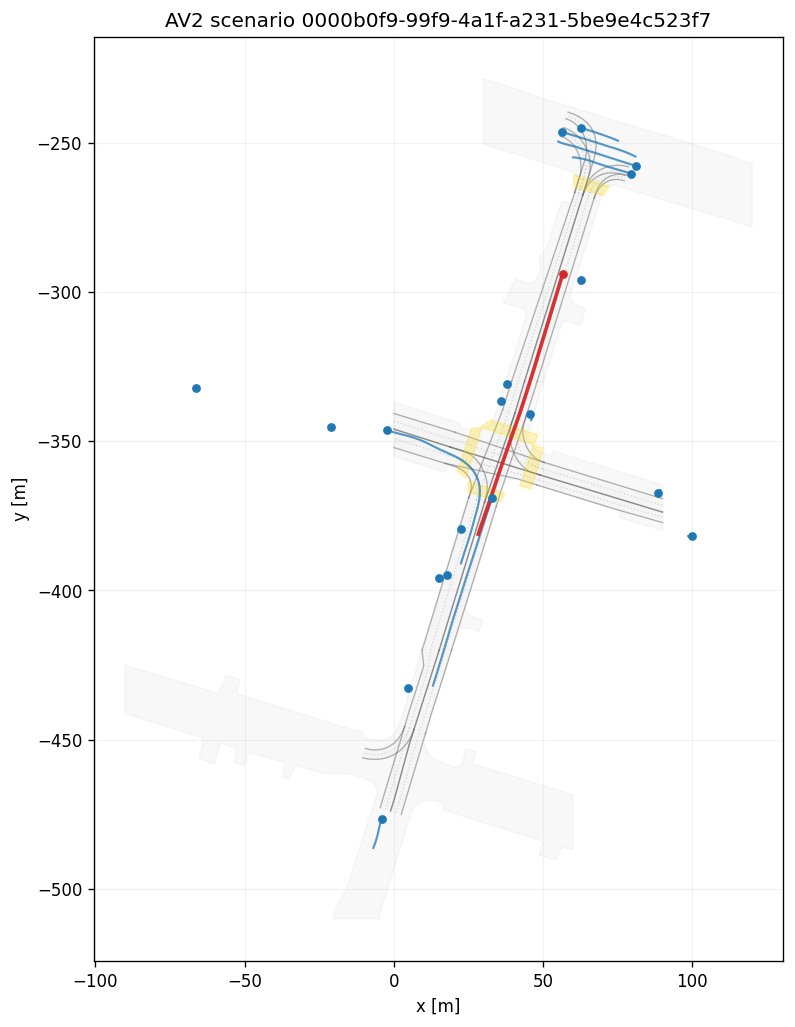

In [9]:
def plot_map_and_tracks(scenario_msg, static_map_obj, df, num_tracks=20, seed=0):
    rng = random.Random(seed)

    fig = Figure(figsize=(10, 10))
    ax = fig.subplots()

    for drivable_area in static_map_obj.vector_drivable_areas.values():
        xy = drivable_area.xyz[:, :2]
        ax.fill(xy[:, 0], xy[:, 1], color='lightgray', alpha=0.15, zorder=0)

    for lane_id, lane_segment in static_map_obj.vector_lane_segments.items():
        polygon = lane_segment.polygon_boundary[:, :2]
        ax.fill(polygon[:, 0], polygon[:, 1], color='whitesmoke', alpha=1.0, zorder=1)

        centerline = static_map_obj.get_lane_segment_centerline(lane_id)[:, :2]
        ax.plot(centerline[:, 0], centerline[:, 1], color='gray', alpha=0.25, linewidth=0.8, linestyle='dotted', zorder=2)

        for boundary in [lane_segment.left_lane_boundary.xyz[:, :2], lane_segment.right_lane_boundary.xyz[:, :2]]:
            ax.plot(boundary[:, 0], boundary[:, 1], color='dimgray', alpha=0.5, linewidth=0.8, zorder=3)

    for crossing in static_map_obj.vector_pedestrian_crossings.values():
        polygon = np.concatenate([crossing.edge1.xyz[:, :2], np.flip(crossing.edge2.xyz[:, :2], axis=0)], axis=0)
        ax.fill(polygon[:, 0], polygon[:, 1], color='gold', alpha=0.25, zorder=4)

    valid = df.dropna(subset=['position_x', 'position_y']).copy()
    track_ids = valid['track_id'].drop_duplicates().tolist()
    chosen = set(rng.sample(track_ids, k=min(num_tracks, len(track_ids))))
    subset = valid[valid['track_id'].isin(chosen)].sort_values(['track_id', 'timestep'])

    focal_track_id = str(scenario_msg.focal_track_id)
    for track_id, group in subset.groupby('track_id'):
        color = 'tab:red' if str(track_id) == focal_track_id else 'tab:blue'
        width = 2.2 if str(track_id) == focal_track_id else 1.3
        alpha = 0.95 if str(track_id) == focal_track_id else 0.75
        ax.plot(group['position_x'], group['position_y'], color=color, linewidth=width, alpha=alpha, zorder=5)
        ax.scatter(group['position_x'].iloc[-1], group['position_y'].iloc[-1], color=color, s=18, zorder=6)

    ax.set_title(f'AV2 scenario {scenario_msg.scenario_id}')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.15)

    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=120, bbox_inches='tight')
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    buffer.close()

plot_map_and_tracks(scenario, static_map, tracks_df, num_tracks=20, seed=42)


## 8) Iterate over multiple scenarios

Use this pattern when building preprocessing, dataset analysis, or dataloaders.

In [10]:
def iter_av2_scenarios(data_root, split, max_scenarios=None):
    split_dir = Path(data_root) / split
    scenario_dirs = sorted(path for path in split_dir.iterdir() if path.is_dir())
    for idx, scenario_dir in enumerate(scenario_dirs):
        if max_scenarios is not None and idx >= max_scenarios:
            break
        scenario_id = scenario_dir.name
        parquet_path = scenario_dir / f'scenario_{scenario_id}.parquet'
        map_path = scenario_dir / f'log_map_archive_{scenario_id}.json'
        yield {
            'scenario_id': scenario_id,
            'scenario_dir': scenario_dir,
            'scenario': scenario_serialization.load_argoverse_scenario_parquet(parquet_path),
            'static_map': ArgoverseStaticMap.from_json(map_path),
        }

for idx, item in enumerate(iter_av2_scenarios(DATASET_ROOT, SELECTED_SPLIT, max_scenarios=3), start=1):
    print(
        f"{idx}. scenario_id={item['scenario_id']}, tracks={len(item['scenario'].tracks)}, lanes={len(item['static_map'].vector_lane_segments)}"
    )


1. scenario_id=0000b0f9-99f9-4a1f-a231-5be9e4c523f7, tracks=56, lanes=25
2. scenario_id=0000b6ab-e100-4f6b-aee8-b520b57c0530, tracks=75, lanes=93
3. scenario_id=0001b567-b7ac-4a91-b4fe-6132e4b81884, tracks=86, lanes=64


## 9) Next steps

- Change `SCENARIO_DIR` to inspect specific train/val/test examples.
- Build per-track or per-scenario statistics from `tracks_df`.
- Reuse the `iter_av2_scenarios(...)` pattern in your datamodule preprocessing.
- If you want richer AV2 plotting, you can also lift details from `utils/viz_av2.py`.